## p(D|t, z, TR) from simulated populations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import R_earth, R_sun, au
from pdetutils import *

import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (10,6)
from matplotlib import rc
rc('text', usetex=False)
import warnings
warnings.filterwarnings("ignore")

In [2]:
class PlanetSampler:
    def __init__(self, df):
        self.period = np.asarray(df.period)
        self.prad = np.asarray(df.planet_radius)
        self.Npl = len(df)

    def sample(self, n):
        idx = np.random.randint(0, self.Npl, n)
        return self.period[idx], self.prad[idx]

    def get_all(self):
        return self.period, self.prad


def marginal_pdet(star, period, prad, cdpp_func, include_transit_prob=False):
    depth_ppm = (prad / star.rad)**2 * 1e6
    dur_hr = 13 * (period / 365.25)**(1./3.) * star.rad * star.Mass**(-1./3.) * np.pi / 4.
    transit_sn = depth_ppm * np.sqrt(star.dataspan * star.dutycycle / period) / cdpp_func(star.kepid, dur_hr)
    transit_prob = (R_sun/au).value * star.rad * (period / 365.25)**(-2./3.) * star.Mass**(-1./3.)
    det_prob = p_det(transit_sn) 
    if include_transit_prob:
        det_prob *= transit_prob
    return np.mean(det_prob)


def compute_marginal_pdet(dkic, psampler, nsample=1000, include_transit_prob=False):
    period, prad = psampler.sample(nsample)
    interp = CDPPInterpolatorByKIC.from_df(dkic, kic_col="KIC")
    probs = []
    for i in range(len(dkic)):
        star = dkic.iloc[i]
        probs.append(marginal_pdet(star, period, prad, interp, include_transit_prob=include_transit_prob))
    probs = np.array(probs)
    return probs

### transiting planet population from simulation

Text(0, 0.5, 'radius (Earth)')

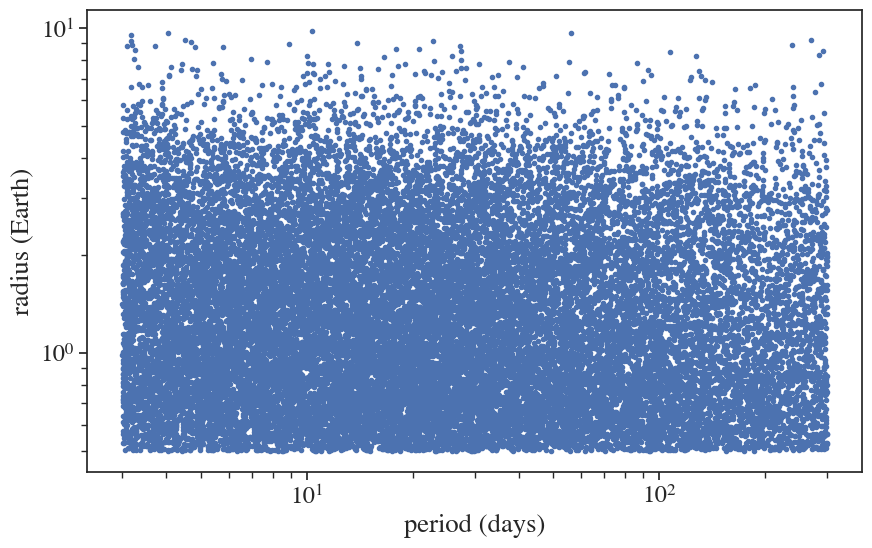

In [10]:
dp = pd.read_csv("../data/physical_catalog.csv", comment='#')
dp['b'] = ((dp['period']/365.25)**2 * dp['star_mass'])**(1./3.) * np.cos(dp['incl']) * (1 - dp['ecc']**2) / (1 + dp['ecc'] * np.sin(dp['omega'])) / dp['star_radius'] * (au / R_sun).value
dtra = dp[np.abs(dp.b) < 1.].reset_index(drop=True)

plt.xscale('log')
plt.yscale('log')
plt.plot(dtra['period'], dtra['planet_radius']*R_sun/R_earth, '.')
plt.xlabel('period (days)')
plt.ylabel('radius (Earth)');

In [4]:
psampler = PlanetSampler(dtra)

### compute pdet

In [5]:
dkic1 = pd.read_csv("../data_m15/m15_kic.csv")
dkic2 = pd.read_csv("../data/DR2PapTable1.txt", delimiter='&')
dkic = pd.merge(dkic1, dkic2[['KIC', 'rad']], on='KIC')
dkic = dkic[dkic['rrmscdpp12p0']==dkic['rrmscdpp12p0']].reset_index(drop=True)

In [6]:
dkic['pdet'] = compute_marginal_pdet(dkic, psampler)
dkic['pdettra'] = compute_marginal_pdet(dkic, psampler, include_transit_prob=True)

In [7]:
dkic.to_csv("m15_kic_w_pdet_TR.csv", index=False)

### plots

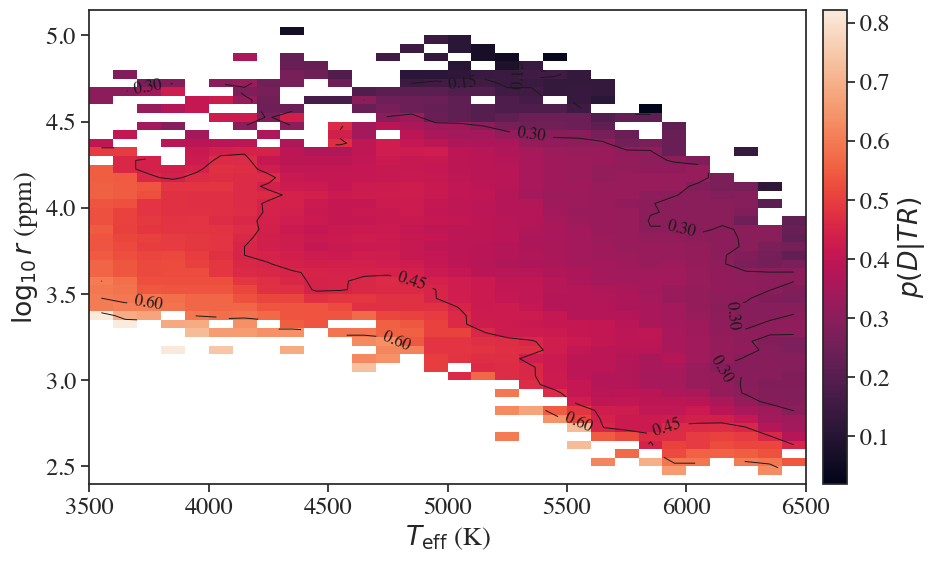

In [11]:
fig = plot_pdet_contour(dkic, xcol='Teff')
fig.savefig('m15_pdet.png', dpi=200, bbox_inches='tight')

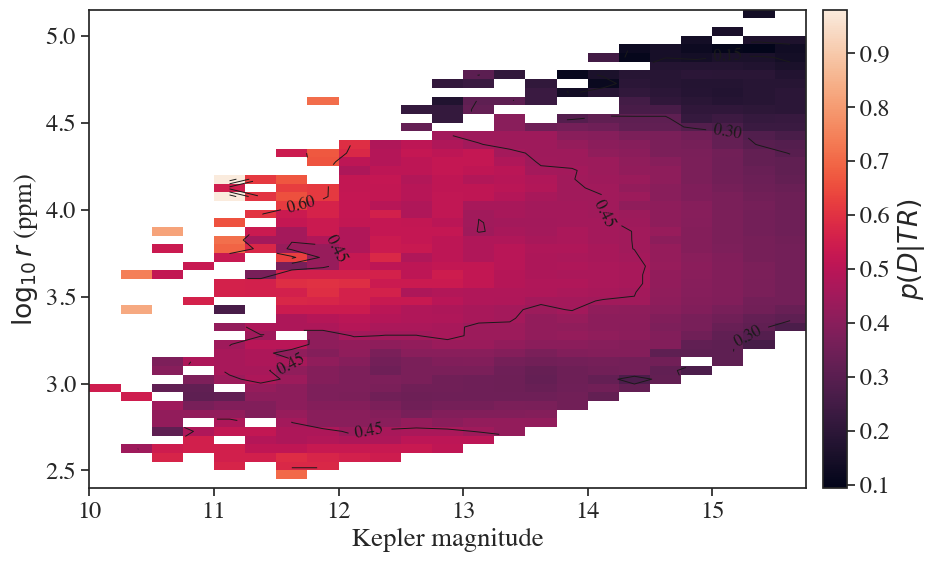

In [12]:
fig = plot_pdet_contour(dkic, xcol='kepmag', x_edges=np.arange(10, 16, 0.25))